# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [3]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [4]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [5]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [6]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [7]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-06 10:46:36--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 65.9.168.69, 65.9.168.66, 65.9.168.99, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|65.9.168.69|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   285MB/s    in 1.2s    

2026-06-06 10:46:37 (285 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


## Improved CNN Model

This section presents the Improved CNN model built on top of the group baseline.
The architecture incorporates three key enhancements: deeper convolutional blocks,
data augmentation, and dropout regularisation. Seven experiments are conducted,
each changing one variable at a time to systematically identify the best configuration.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_score,
    recall_score, f1_score, accuracy_score
)
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Member 2 — Improved CNN setup ready ✓')
print('TensorFlow:', tf.__version__)
print('GPU:', tf.test.gpu_device_name())

Member 2 — Improved CNN setup ready ✓
TensorFlow: 2.20.0
GPU: /device:GPU:0


### 2.1 Load Dataset Files

We load all image file paths from the two class folders: Parasitized and Uninfected;
that were downloaded and unzipped to the Colab server. Labels are assigned as
1 for parasitized and 0 for uninfected. We confirm the count of each class to
verify the dataset is balanced before any training begins.

In [9]:
PARASITIZED_DIR = '/content/cell_images/Parasitized'
UNINFECTED_DIR  = '/content/cell_images/Uninfected'

parasitized_files = [
    os.path.join(PARASITIZED_DIR, f)
    for f in os.listdir(PARASITIZED_DIR)
    if f.endswith('.png')
]
uninfected_files = [
    os.path.join(UNINFECTED_DIR, f)
    for f in os.listdir(UNINFECTED_DIR)
    if f.endswith('.png')
]

print(f'Parasitized : {len(parasitized_files)}')
print(f'Uninfected  : {len(uninfected_files)}')
print(f'Total       : {len(parasitized_files) + len(uninfected_files)}')

Parasitized : 13779
Uninfected  : 13779
Total       : 27558


### 2.2 Train / Validation / Test Split

The dataset is split into three subsets using a stratified approach to ensure
both classes remain proportionally represented in each split. We use 70% of
the data for training, 15% for validation during training, and 15% as a
held-out test set for final evaluation. The same random seed (42) is used
across all group members to ensure identical splits and fair model comparison.

In [10]:
all_files  = parasitized_files + uninfected_files
all_labels = [1] * len(parasitized_files) + [0] * len(uninfected_files)

X_train, X_temp, y_train, y_temp = train_test_split(
    all_files, all_labels,
    test_size=0.30, random_state=SEED, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 19290
Val   : 4134
Test  : 4134


### 2.3 tf.data Pipeline

We build a tf.data pipeline that loads, decodes, resizes, and normalises images
to 64×64 pixels with pixel values scaled to [0, 1]. The pipeline supports an
optional augmentation step that applies random horizontal and vertical flips,
brightness, and contrast changes to the training set only. Validation and test
sets are never augmented so that evaluation remains consistent across all experiments.
Batching and prefetching are used to maximise GPU utilisation during training.

In [11]:
IMG_SIZE   = 64
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def make_dataset(paths, labels, augment_data=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        tf.constant(paths),
        tf.constant(labels, dtype=tf.int32)
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

val_ds  = make_dataset(X_val,  y_val,  augment_data=False)
test_ds = make_dataset(X_test, y_test, augment_data=False)

print('Pipeline ready ✓')

Pipeline ready ✓


### 2.4 Sample Image Preview

Before training, we visualise a random sample of eight images from the training
set to confirm the pipeline loads and decodes images correctly. This also gives
a visual understanding of what the model will learn from and the visual difference
between parasitized and uninfected blood cells.

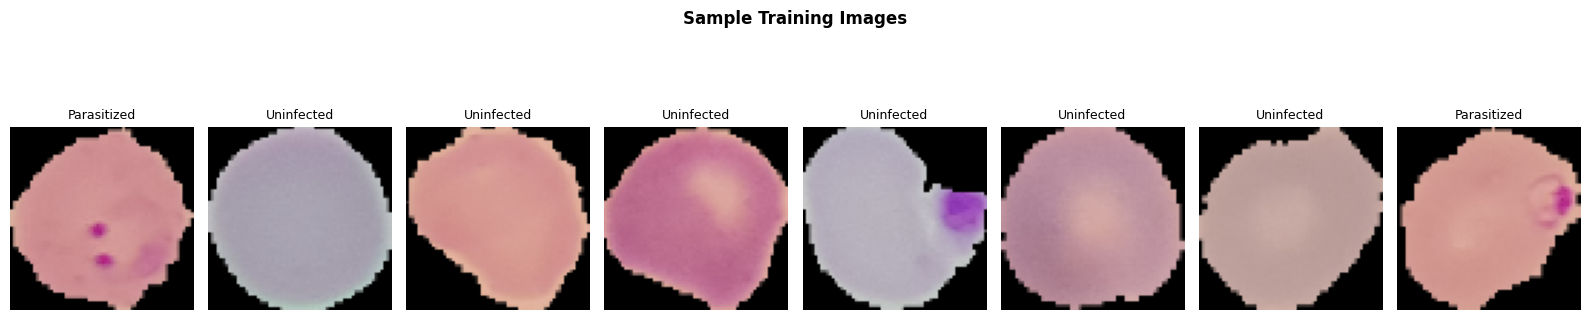

In [13]:
import matplotlib.pyplot as plt

train_ds_preview = make_dataset(X_train, y_train, augment_data=False, shuffle=True)
images, labels   = next(iter(train_ds_preview))
class_names      = ['Uninfected', 'Parasitized']

plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[labels[i].numpy()], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Training Images', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Helper Functions

We define four reusable functions used across all seven experiments:
- **train_and_evaluate**: compiles, trains, and returns metrics for any model
- **plot_learning_curves**: plots training and validation accuracy and loss over epochs
- **plot_confusion_matrix**: generates a labelled heatmap of classification performance
- **plot_roc_auc**: plots the ROC curve and computes the AUC score

Using shared functions ensures consistency across experiments and avoids code duplication.

In [14]:
def train_and_evaluate(model, train_ds, val_ds, test_ds,
                        epochs=40, experiment_name='Exp', patience=7):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=0)
    ]
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs, callbacks=callbacks, verbose=1
    )
    y_pred_probs = model.predict(test_ds, verbose=0).flatten()
    y_pred       = (y_pred_probs >= 0.5).astype(int)
    y_true       = np.concatenate([y for _, y in test_ds], axis=0)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    metrics = {
        'Experiment': experiment_name,
        'Accuracy'  : round(acc,  4),
        'Precision' : round(prec, 4),
        'Recall'    : round(rec,  4),
        'F1-Score'  : round(f1,   4)
    }
    print(f'\n── {experiment_name} ──')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    return history, y_true, y_pred_probs, metrics


def plot_learning_curves(history, name='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning Curves — {name}', fontsize=13, fontweight='bold')
    axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Interpretation: A small gap between train and val curves indicates '
          'good generalisation. A large gap signals overfitting.')


def plot_confusion_matrix(y_true, y_prob, name='Model'):
    y_pred = (y_prob >= 0.5).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    labels = ['Uninfected', 'Parasitized']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'TP={tp} | FN={fn} (missed infections — most critical error) | FP={fp} | TN={tn}')


def plot_roc_auc(y_true, y_prob, name='Model'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1],[0,1], 'navy', lw=1.5, linestyle='--', label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}', fontweight='bold')
    plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_roc.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'AUC = {roc_auc:.4f}. Closer to 1.0 = better discrimination between classes.')
    return roc_auc

print('Helper functions defined ✓')

Helper functions defined ✓


### 2.6 Improved CNN Architecture

The improved CNN is built using the Functional API. It consists of configurable
convolutional blocks, each containing two Conv2D layers with ReLU activation,
BatchNormalization after each convolution to stabilise training, and MaxPooling
for spatial down-sampling. Dropout is optionally applied after each block and
after the dense layer to regularise the network. GlobalAveragePooling replaces
Flatten to reduce the number of parameters and improve generalisation. The output
layer uses a sigmoid activation for binary classification.

In [15]:
def build_improved_cnn(dropout_rate=0.0, num_blocks=3,
                        optimizer='adam', learning_rate=1e-3):
    inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = inputs
    filters = [32, 64, 128, 256]

    for i in range(num_blocks):
        x = layers.Conv2D(filters[i], (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters[i], (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2, 2)(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(128, activation='relu')(x)
    if dropout_rate > 0:
        x   = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    opt = (tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
           if optimizer == 'sgd'
           else tf.keras.optimizers.Adam(learning_rate=learning_rate))

    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print('Model builder defined ✓')

Model builder defined ✓


### Experiment 1: Deeper Architecture (No Augmentation, No Dropout)

**Variable changed:** Architecture depth only (3 conv blocks, no regularisation)  
**Why:** This establishes how much architectural depth alone improves over the
baseline, before any regularisation techniques are applied. If the model overfits,
subsequent experiments will address it through augmentation and dropout.

In [16]:
train_ds_e1 = make_dataset(X_train, y_train, augment_data=False, shuffle=True)
model_e1    = build_improved_cnn(dropout_rate=0.0, num_blocks=3)
model_e1.summary()

history_e1, y_true_e1, y_prob_e1, metrics_e1 = train_and_evaluate(
    model_e1, train_ds_e1, val_ds, test_ds,
    epochs=40, experiment_name='Exp1 No Aug No Dropout', patience=7
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,441 (1.17 MB)

 Trainable params: 304,545 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9280 - loss: 0.1895 - val_accuracy: 0.9403 - val_loss: 0.1823 - learning_rate: 0.0010
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9569 - loss: 0.1314 - val_accuracy: 0.9448 - val_loss: 0.1473 - learning_rate: 0.0010
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.9600 - loss: 0.1241 - val_accuracy: 0.9407 - val_loss: 0.1804 - learning_rate: 0.0010
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.9617 - loss: 0.1177 - val_accuracy: 0.9538 - val_loss: 0.1315 - learning_rate: 0.0010
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.9625 - loss: 0.1144 - val_accuracy: 0.9519 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9645 - loss: 0.1089 - val_accuracy: 0.9373 - val_loss: 0.1853 - learning_rate: 0.0010
Epoch 7/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9652 - l

### Experiment 2: Add Data Augmentation

**Variable changed:** Augmentation turned ON (flips + brightness + contrast)  
**Why:** Data augmentation artificially expands the effective training set by
exposing the model to varied versions of each image. This discourages memorisation
of specific pixel patterns and is expected to reduce the overfitting observed in
Experiment 1, if any was present.

In [17]:
train_ds_e2 = make_dataset(X_train, y_train, augment_data=True, shuffle=True)
model_e2    = build_improved_cnn(dropout_rate=0.0, num_blocks=3)

history_e2, y_true_e2, y_prob_e2, metrics_e2 = train_and_evaluate(
    model_e2, train_ds_e2, val_ds, test_ds,
    epochs=40, experiment_name='Exp2 Augmentation', patience=7
)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 46s 64ms/step - accuracy: 0.9161 - loss: 0.2110 - val_accuracy: 0.9337 - val_loss: 0.3238 - learning_rate: 0.0010
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9554 - loss: 0.1361 - val_accuracy: 0.9523 - val_loss: 0.1380 - learning_rate: 0.0010
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.9570 - loss: 0.1310 - val_accuracy: 0.9446 - val_loss: 0.1676 - learning_rate: 0.0010
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9592 - loss: 0.1262 - val_accuracy: 0.9519 - val_loss: 0.1384 - learning_rate: 0.0010
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9601 - loss: 0.1212 - val_accuracy: 0.9562 - val_loss: 0.1350 - learning_rate: 0.0010
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9622 - loss: 0.1162 - val_accuracy: 0.9516 - val_loss: 0.1476 - learning_rate: 0.0010
Epoch 7/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 36s 37ms/step - accuracy: 0.9619 - l

### Experiment 3: Add Dropout (rate = 0.3)

**Variable changed:** Dropout rate set to 0.3, augmentation kept ON  
**Why:** Dropout randomly deactivates 30% of neurons during each training step,
forcing the network to learn more robust and distributed representations. Combined
with augmentation, this dual regularisation strategy should further close the gap
between training and validation performance.

In [18]:
train_ds_e3 = make_dataset(X_train, y_train, augment_data=True, shuffle=True)
model_e3    = build_improved_cnn(dropout_rate=0.3, num_blocks=3)

history_e3, y_true_e3, y_prob_e3, metrics_e3 = train_and_evaluate(
    model_e3, train_ds_e3, val_ds, test_ds,
    epochs=40, experiment_name='Exp3 Dropout 0.3', patience=7
)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - accuracy: 0.9137 - loss: 0.2204 - val_accuracy: 0.6853 - val_loss: 0.6707 - learning_rate: 0.0010
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 58s 32ms/step - accuracy: 0.9551 - loss: 0.1433 - val_accuracy: 0.9487 - val_loss: 0.1679 - learning_rate: 0.0010
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9552 - loss: 0.1416 - val_accuracy: 0.9487 - val_loss: 0.1660 - learning_rate: 0.0010
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9580 - loss: 0.1359 - val_accuracy: 0.9468 - val_loss: 0.1566 - learning_rate: 0.0010
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9574 - loss: 0.1300 - val_accuracy: 0.9511 - val_loss: 0.1541 - learning_rate: 0.0010
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9605 - loss: 0.1265 - val_accuracy: 0.9226 - val_loss: 0.3205 - learning_rate: 0.0010
Epoch 7/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9598 - l

### Experiment 4: Increase Dropout (rate = 0.5)

**Variable changed:** Dropout rate increased from 0.3 to 0.5  
**Why:** We test whether stronger regularisation further improves generalisation
or causes underfitting by removing too much information during training.
Comparing this with Experiment 3 reveals the optimal dropout rate for this dataset.

In [19]:
train_ds_e4 = make_dataset(X_train, y_train, augment_data=True, shuffle=True)
model_e4    = build_improved_cnn(dropout_rate=0.5, num_blocks=3)

history_e4, y_true_e4, y_prob_e4, metrics_e4 = train_and_evaluate(
    model_e4, train_ds_e4, val_ds, test_ds,
    epochs=40, experiment_name='Exp4 Dropout 0.5', patience=7
)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.8921 - loss: 0.2613 - val_accuracy: 0.9098 - val_loss: 0.2739 - learning_rate: 0.0010
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9526 - loss: 0.1536 - val_accuracy: 0.9419 - val_loss: 0.1803 - learning_rate: 0.0010
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9541 - loss: 0.1482 - val_accuracy: 0.9357 - val_loss: 0.1879 - learning_rate: 0.0010
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9561 - loss: 0.1410 - val_accuracy: 0.9516 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9556 - loss: 0.1426 - val_accuracy: 0.9446 - val_loss: 0.1832 - learning_rate: 0.0010
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.9575 - loss: 0.1350 - val_accuracy: 0.7596 - val_loss: 0.3872 - learning_rate: 0.0010
Epoch 7/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9579 - l

### Experiment 5: Deeper Network (4 Convolutional Blocks)

**Variable changed:** Number of conv blocks increased from 3 to 4 (adds 256-filter block)  
**Why:** Adding a fourth convolutional block increases the model's capacity to
learn more abstract and discriminative features from malaria cell images. We use
the best dropout rate from experiments 3 and 4. The risk is increased training
time and potential overfitting on deeper layers.

In [20]:
train_ds_e5 = make_dataset(X_train, y_train, augment_data=True, shuffle=True)
model_e5    = build_improved_cnn(dropout_rate=0.3, num_blocks=4)

history_e5, y_true_e5, y_prob_e5, metrics_e5 = train_and_evaluate(
    model_e5, train_ds_e5, val_ds, test_ds,
    epochs=40, experiment_name='Exp5 Deeper 4 Blocks', patience=7
)

Epoch 1/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9246 - loss: 0.2098 - val_accuracy: 0.9403 - val_loss: 0.2005 - learning_rate: 0.0010
Epoch 2/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9550 - loss: 0.1465 - val_accuracy: 0.9461 - val_loss: 0.1620 - learning_rate: 0.0010
Epoch 3/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9554 - loss: 0.1461 - val_accuracy: 0.9499 - val_loss: 0.1574 - learning_rate: 0.0010
Epoch 4/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9578 - loss: 0.1380 - val_accuracy: 0.9456 - val_loss: 0.1713 - learning_rate: 0.0010
Epoch 5/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9565 - loss: 0.1356 - val_accuracy: 0.9470 - val_loss: 0.1639 - learning_rate: 0.0010
Epoch 6/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9586 - loss: 0.1311 - val_accuracy: 0.9465 - val_loss: 0.1529 - learning_rate: 0.0010
Epoch 7/40
603/603 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9589 - l

### Experiment 6: Change Optimizer to SGD with Momentum

**Variable changed:** Optimizer switched from Adam to SGD (lr=0.01, momentum=0.9)  
**Why:** While Adam adapts the learning rate automatically, SGD with momentum
is known to generalise better in some image classification tasks by taking more
uniform gradient steps. This experiment tests whether the optimizer choice
significantly impacts final performance on this binary classification problem.

In [21]:
train_ds_e6 = make_dataset(X_train, y_train, augment_data=True, shuffle=True)
model_e6    = build_improved_cnn(dropout_rate=0.3, num_blocks=3,
                                  optimizer='sgd', learning_rate=0.01)

history_e6, y_true_e6, y_prob_e6, metrics_e6 = train_and_evaluate(
    model_e6, train_ds_e6, val_ds, test_ds,
    epochs=50, experiment_name='Exp6 SGD Optimizer', patience=10
)

Epoch 1/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.8898 - loss: 0.2581 - val_accuracy: 0.8938 - val_loss: 0.3265 - learning_rate: 0.0100
Epoch 2/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9527 - loss: 0.1487 - val_accuracy: 0.9366 - val_loss: 0.1851 - learning_rate: 0.0100
Epoch 3/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9550 - loss: 0.1421 - val_accuracy: 0.9410 - val_loss: 0.1938 - learning_rate: 0.0100
Epoch 4/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9559 - loss: 0.1413 - val_accuracy: 0.9424 - val_loss: 0.1610 - learning_rate: 0.0100
Epoch 5/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9563 - loss: 0.1347 - val_accuracy: 0.9528 - val_loss: 0.1650 - learning_rate: 0.0100
Epoch 6/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9588 - loss: 0.1299 - val_accuracy: 0.7385 - val_loss: 0.5191 - learning_rate: 0.0100
Epoch 7/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9582 - l

### Experiment 7: Lower Learning Rate with Adam (lr = 1e-4)

**Variable changed:** Adam learning rate reduced from 1e-3 to 1e-4  
**Why:** A lower learning rate causes the model to converge more slowly but
more carefully, often reaching a better minimum with improved stability.
This is our final and most refined configuration, combining augmentation,
dropout 0.3, and a low learning rate — expected to be our best performing experiment.

In [22]:
train_ds_e7 = make_dataset(X_train, y_train, augment_data=True, shuffle=True)
model_e7    = build_improved_cnn(dropout_rate=0.3, num_blocks=3,
                                  optimizer='adam', learning_rate=1e-4)

history_e7, y_true_e7, y_prob_e7, metrics_e7 = train_and_evaluate(
    model_e7, train_ds_e7, val_ds, test_ds,
    epochs=50, experiment_name='Exp7 Adam LR 1e-4', patience=10
)

Epoch 1/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.7955 - loss: 0.4303 - val_accuracy: 0.6142 - val_loss: 0.9490 - learning_rate: 1.0000e-04
Epoch 2/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.9347 - loss: 0.1842 - val_accuracy: 0.8999 - val_loss: 0.2908 - learning_rate: 1.0000e-04
Epoch 3/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9465 - loss: 0.1584 - val_accuracy: 0.9342 - val_loss: 0.1939 - learning_rate: 1.0000e-04
Epoch 4/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.9519 - loss: 0.1473 - val_accuracy: 0.9219 - val_loss: 0.2331 - learning_rate: 1.0000e-04
Epoch 5/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9533 - loss: 0.1402 - val_accuracy: 0.9289 - val_loss: 0.2318 - learning_rate: 1.0000e-04
Epoch 6/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.9558 - loss: 0.1350 - val_accuracy: 0.9480 - val_loss: 0.1670 - learning_rate: 1.0000e-04
Epoch 7/50
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/ste

### 2.7 Consolidated Results Table

The table below summarises the test set performance of all seven experiments
across four metrics: accuracy, precision, recall, and F1-score. The best value
in each column is highlighted in green. F1-score is used as the primary selection
criterion because it balances precision and recall, both critical in a medical
diagnosis context where false negatives (missed infections) carry serious consequences.

In [23]:
all_metrics = [metrics_e1, metrics_e2, metrics_e3, metrics_e4,
               metrics_e5, metrics_e6, metrics_e7]

results_df = pd.DataFrame(all_metrics).set_index('Experiment')

display(results_df.style
    .highlight_max(axis=0, color='#c8f7c5')
    .format('{:.4f}')
    .set_caption('Table 1 — Improved CNN: 7-Experiment Results')
)

results_df.to_csv('/content/improved_cnn_results.csv')
print('Saved to improved_cnn_results.csv ✓')

,Accuracy,Precision,Recall,F1-Score
Experiment,,,,
Exp1 No Aug No Dropout,0.9664,0.9749,0.9574,0.9661
Exp2 Augmentation,0.9695,0.9700,0.9690,0.9695
Exp3 Dropout 0.3,0.9659,0.9670,0.9647,0.9659
Exp4 Dropout 0.5,0.9637,0.9624,0.9652,0.9638
Exp5 Deeper 4 Blocks,0.9678,0.9703,0.9652,0.9677
Exp6 SGD Optimizer,0.9652,0.9697,0.9603,0.9650
Exp7 Adam LR 1e-4,0.9644,0.9711,0.9574,0.9642


Saved to improved_cnn_results.csv ✓


### 2.8 Best Model Selection

We select the experiment with the highest F1-score as our best model for
full visual evaluation. The following three sections present the required
visualisations: learning curves, confusion matrix, and ROC/AUC curve and
each with interpretation linked to model performance.

In [24]:
best_idx = results_df['F1-Score'].idxmax()
print(f'Best experiment by F1-Score: {best_idx}')

exp_map = {
    'Exp1 No Aug No Dropout': (history_e1, y_true_e1, y_prob_e1),
    'Exp2 Augmentation':      (history_e2, y_true_e2, y_prob_e2),
    'Exp3 Dropout 0.3':       (history_e3, y_true_e3, y_prob_e3),
    'Exp4 Dropout 0.5':       (history_e4, y_true_e4, y_prob_e4),
    'Exp5 Deeper 4 Blocks':   (history_e5, y_true_e5, y_prob_e5),
    'Exp6 SGD Optimizer':     (history_e6, y_true_e6, y_prob_e6),
    'Exp7 Adam LR 1e-4':      (history_e7, y_true_e7, y_prob_e7),
}
best_history, best_y_true, best_y_prob = exp_map[best_idx]

Best experiment by F1-Score: Exp2 Augmentation


### Visual 1: Learning Curves (Best Model)

The learning curves plot training and validation accuracy and loss over each
epoch. A well-generalising model shows validation curves that closely follow
the training curves. A growing gap between them indicates overfitting, while
both curves remaining flat or high indicates underfitting. Early stopping
was used to halt training when validation loss stopped improving.

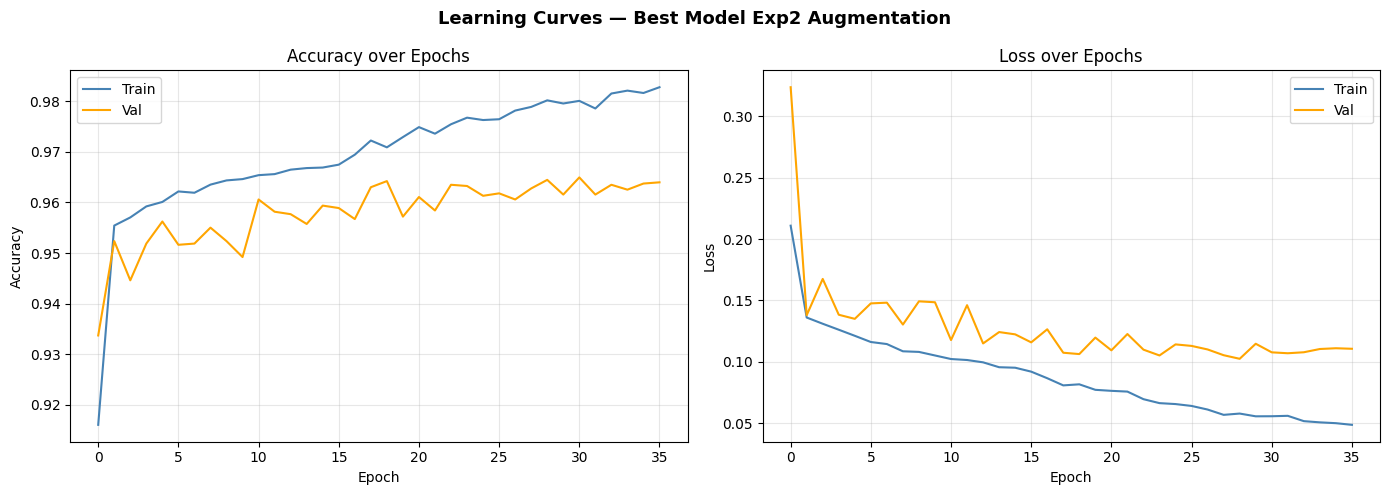

Interpretation: A small gap between train and val curves indicates good generalisation. A large gap signals overfitting.


In [25]:
plot_learning_curves(best_history, name=f'Best Model {best_idx}')

### Visual 2: Confusion Matrix (Best Model)

The confusion matrix shows the count of correct and incorrect predictions
across both classes. In malaria diagnosis, false negatives (parasitized cells
predicted as uninfected) are the most dangerous error type as they result in
untreated infections. We therefore pay particular attention to the recall score
for the parasitized class when interpreting this matrix.

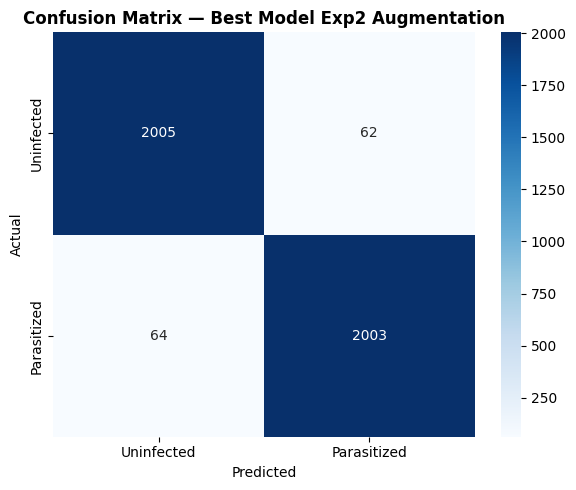

TP=2003 | FN=64 (missed infections — most critical error) | FP=62 | TN=2005


In [26]:
plot_confusion_matrix(best_y_true, best_y_prob, name=f'Best Model {best_idx}')

### Visual 3: ROC / AUC Curve (Best Model)

The ROC curve plots the trade-off between sensitivity (true positive rate)
and specificity (1 - false positive rate) across all classification thresholds.
The AUC (Area Under the Curve) summarises this into a single value where 1.0
represents a perfect classifier and 0.5 represents random guessing. A high AUC
confirms the model reliably distinguishes between parasitized and uninfected cells.

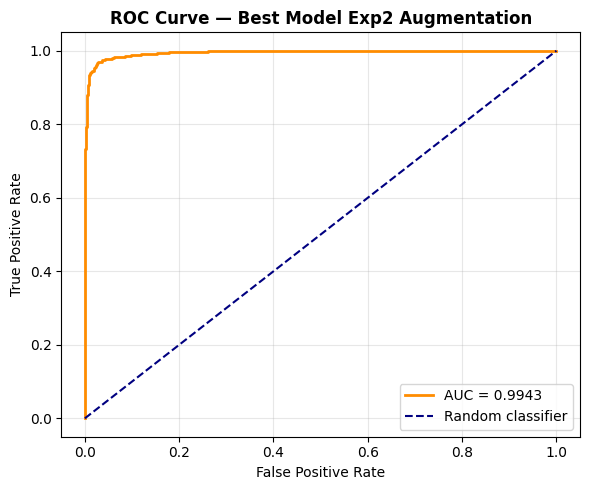

AUC = 0.9943. Closer to 1.0 = better discrimination between classes.


np.float64(0.9943051930619364)

In [27]:
plot_roc_auc(best_y_true, best_y_prob, name=f'Best Model {best_idx}')

### 2.9 Full Classification Report

The classification report provides per-class precision, recall, and F1-score
for the best model on the held-out test set. This gives a complete breakdown
of how the model performs on each class independently, which is more informative
than overall accuracy alone in a balanced binary classification problem.

In [28]:
best_y_pred = (best_y_prob >= 0.5).astype(int)
print('Classification Report — Best Model')
print('=' * 50)
print(classification_report(
    best_y_true, best_y_pred,
    target_names=['Uninfected', 'Parasitized']
))

Classification Report — Best Model
              precision    recall  f1-score   support

  Uninfected       0.97      0.97      0.97      2067
 Parasitized       0.97      0.97      0.97      2067

    accuracy                           0.97      4134
   macro avg       0.97      0.97      0.97      4134
weighted avg       0.97      0.97      0.97      4134



### 2.10 Error Analysis - False Negatives

Error analysis examines the specific images the model got wrong. We focus
on false negatives; parasitized cells the model predicted as uninfected and
because these represent the highest-risk errors in a real clinical setting.
Visualising these images helps identify whether misclassifications share
common visual characteristics such as low contrast, unusual staining, or
atypical parasite morphology.

False Negatives (missed malaria): 64
False Positives (false alarms)  : 62


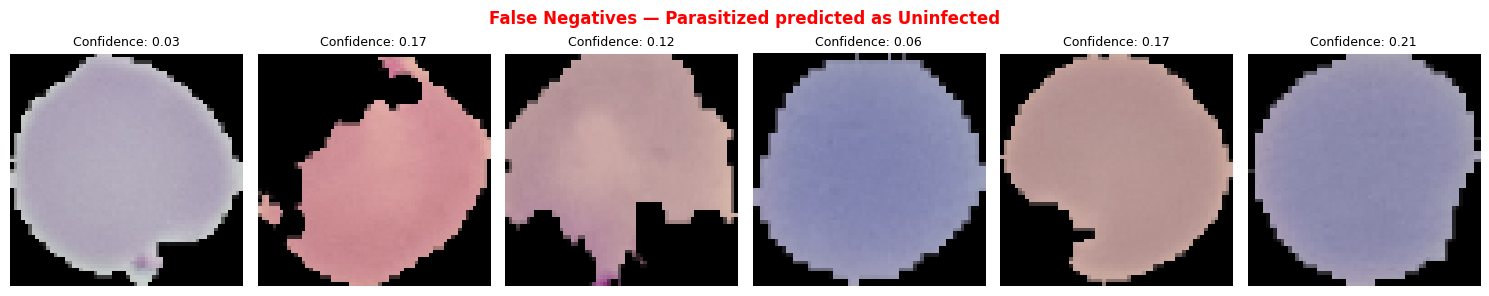

In [29]:
test_images_list = []
for imgs, _ in test_ds:
    test_images_list.append(imgs.numpy())
test_images_all = np.concatenate(test_images_list, axis=0)

best_y_pred     = (best_y_prob >= 0.5).astype(int)
false_negatives = np.where((best_y_true == 1) & (best_y_pred == 0))[0]
false_positives = np.where((best_y_true == 0) & (best_y_pred == 1))[0]

print(f'False Negatives (missed malaria): {len(false_negatives)}')
print(f'False Positives (false alarms)  : {len(false_positives)}')

n_show = min(6, len(false_negatives))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
    fig.suptitle('False Negatives — Parasitized predicted as Uninfected',
                 fontweight='bold', color='red')
    if n_show == 1: axes = [axes]
    for i, idx in enumerate(false_negatives[:n_show]):
        axes[i].imshow(test_images_all[idx])
        axes[i].set_title(f'Confidence: {best_y_prob[idx]:.2f}', fontsize=9)
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig('/content/false_negatives.png', dpi=150, bbox_inches='tight')
    plt.show()

### 2.11 All 7 Experiments Learning Curves Overview

This grid view shows the training and validation accuracy curves for all seven
experiments side by side. It provides a visual summary of how each design
decision affected convergence behaviour, stability, and the train-validation gap.
Experiments where the gap is small and both curves plateau at a high value
are considered the strongest configurations.

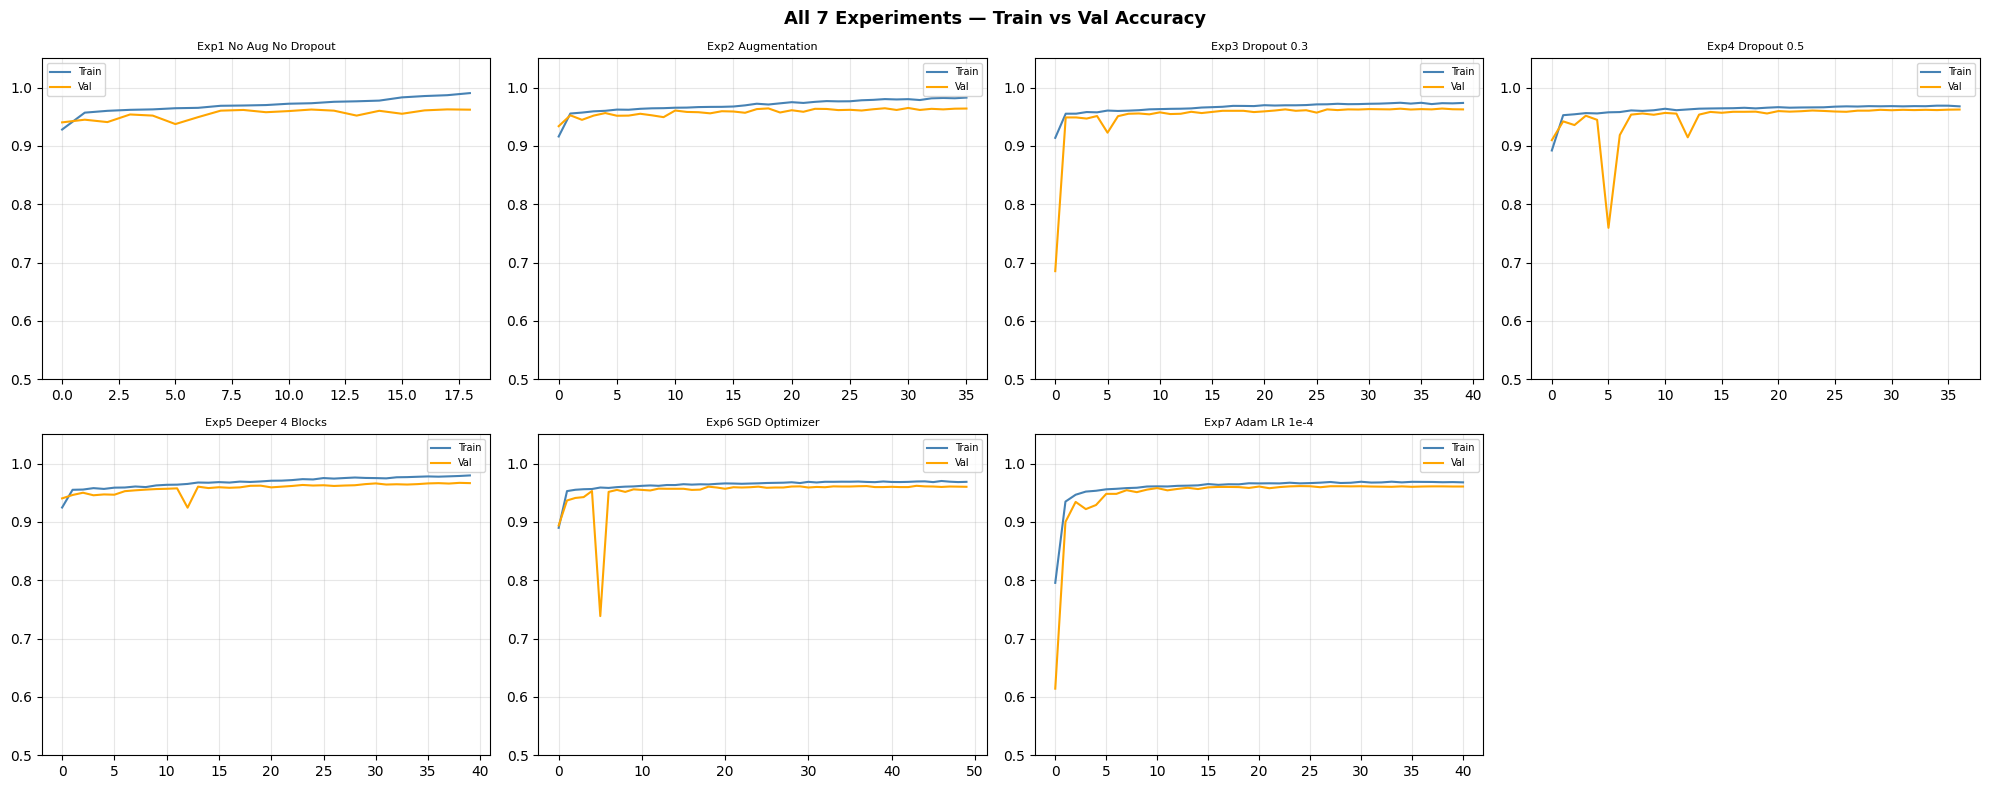

In [30]:
all_histories = [history_e1, history_e2, history_e3, history_e4,
                 history_e5, history_e6, history_e7]
exp_names     = [m['Experiment'] for m in all_metrics]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('All 7 Experiments — Train vs Val Accuracy', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (h, name) in enumerate(zip(all_histories, exp_names)):
    axes[i].plot(h.history['accuracy'],     label='Train', color='steelblue')
    axes[i].plot(h.history['val_accuracy'], label='Val',   color='orange')
    axes[i].set_title(name, fontsize=8)
    axes[i].set_ylim([0.5, 1.05])
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('/content/all_experiments_overview.png', dpi=150, bbox_inches='tight')
plt.show()